11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 313s 27us/step


C:\Users\T H I N K P A D\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - accuracy: 0.8922 - loss: 0.3485 - val_accuracy: 0.9865 - val_loss: 0.0447
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.9852 - loss: 0.0486 - val_accuracy: 0.9875 - val_loss: 0.0441
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.9903 - loss: 0.0302 - val_accuracy: 0.9892 - val_loss: 0.0365
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.9936 - loss: 0.0212 - val_accuracy: 0.9898 - val_loss: 0.0343
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.9947 - loss: 0.0168 - val_accuracy: 0.9903 - val_loss: 0.0402
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9827 - loss: 0.0508

Test Accuracy: 0.9863
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


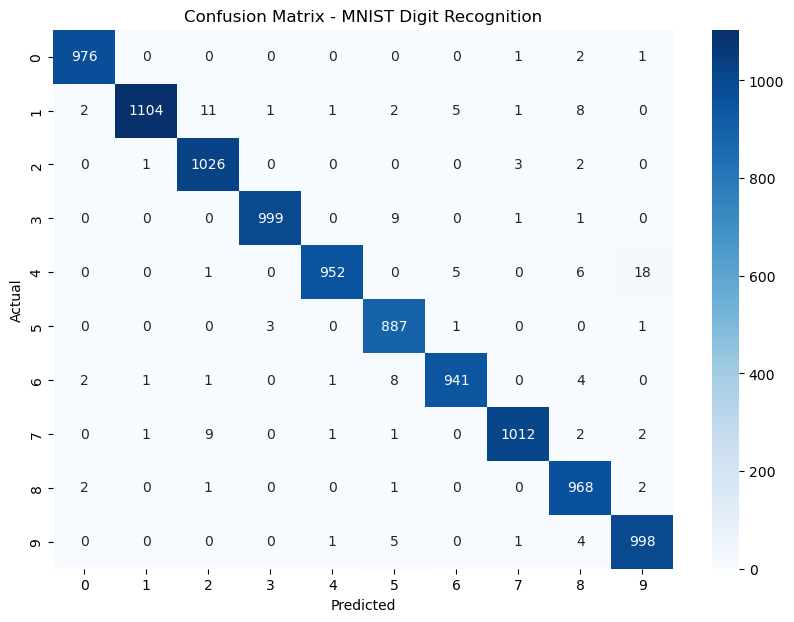


Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      0.97      0.98      1135
           2       0.98      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       1.00      0.97      0.98       982
           5       0.97      0.99      0.98       892
           6       0.99      0.98      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.97      0.99      0.98       974
           9       0.98      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [2]:
# Import libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the data (pixel values from [0, 255] to [0, 1])
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape for CNN input (batch, height, width, channels)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# -------------------------------
# 🧠 Build CNN Model
# -------------------------------
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 output classes (0-9)
])

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# -------------------------------
# 📈 Train the model
# -------------------------------
model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# -------------------------------
# 🎯 Evaluate the model
# -------------------------------
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")

# -------------------------------
# 🔍 Confusion Matrix
# -------------------------------
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - MNIST Digit Recognition")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Optional: Print classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))


C:\Users\T H I N K P A D\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.9040 - loss: 0.3113 - val_accuracy: 0.9888 - val_loss: 0.0404
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.9860 - loss: 0.0439 - val_accuracy: 0.9885 - val_loss: 0.0437
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.9918 - loss: 0.0257 - val_accuracy: 0.9905 - val_loss: 0.0336
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.9936 - loss: 0.0198 - val_accuracy: 0.9875 - val_loss: 0.0438
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.9951 - loss: 0.0138 - val_accuracy: 0.9922 - val_loss: 0.0317
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9886 - loss: 0.0357

Test Accuracy: 0.9917
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


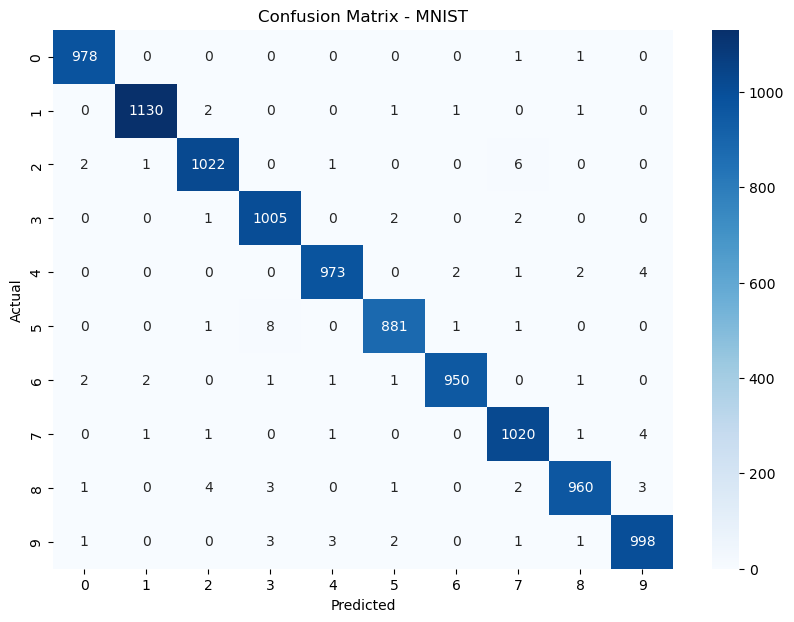


Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [3]:
# Import libraries
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------
# 📄 Load CSV datasets
# ------------------------------
train_df = pd.read_csv("mnist_train.csv")
test_df = pd.read_csv("mnist_test.csv")

# ------------------------------
# 🎯 Split features and labels
# ------------------------------
# First column = label, rest = pixels
x_train = train_df.iloc[:, 1:].values
y_train = train_df.iloc[:, 0].values

x_test = test_df.iloc[:, 1:].values
y_test = test_df.iloc[:, 0].values

# ------------------------------
# 🧼 Normalize and reshape data
# ------------------------------
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape to (28, 28, 1) for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# ------------------------------
# 🧠 Build CNN model
# ------------------------------
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 digits (0 to 9)
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ------------------------------
# 🚀 Train the model
# ------------------------------
model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# ------------------------------
# 🎯 Evaluate + Confusion Matrix
# ------------------------------
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Predict and generate confusion matrix
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - MNIST")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
